# 🇵🇰 Pak Constitution AI: End-to-End QLoRA Fine-Tuning
This notebook implements the fine-tuning of Llama-3-8B using **QLoRA (Quantized Low-Rank Adaptation)** on the Constitution of the Islamic Republic of Pakistan.


# Drive Mounting & Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Libraries Installation

In [2]:
!pip install -q torch transformers datasets peft trl bitsandbytes accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 24.4 MB/s eta 0:00:00


## 2. Hugging Face Login
Authenticate with Hugging Face to enable seamless model deployment and pushing adapters to the Hub.

In [3]:
from huggingface_hub import notebook_login
notebook_login()

## 3. Data Extraction & Preprocessing
Extract raw text from the official Constitution PDF file stored in Google Drive and transform it into JSONL format (`instruction`, `input`, `output`) suitable for causal language modeling.

In [4]:
# 1. PDF reader library install
!pip install -q pypdf

from pypdf import PdfReader
import json
import os

# Google Drive file path
file_path = '/content/gdrive/MyDrive/Fine Tuning/THE CONSTITUTION OF THE ISLAMIC REPUBLIC OF PAKISTAN.pdf'

print("Extracting text from PDF...")
reader = PdfReader(file_path)
text = ""

for i, page in enumerate(reader.pages):
    extracted_text = page.extract_text()
    if extracted_text:
        text += extracted_text + "\n"

print(f"Total text extracted: {len(text)} characters.")

# 2. Preprocessing & Saving to JSONL format
os.makedirs("data", exist_ok=True)
output_file = "data/constitution_train.jsonl"

sections = text.split("Article")
dataset = []

for section in sections:
    if len(section.strip()) > 50:
        cleaned_section = section.replace("\n", " ").strip()

        dataset.append({
            "instruction": "Explain the constitutional provision of the Islamic Republic of Pakistan based on the Article.",
            "input": cleaned_section[:300] + "...",
            "output": f"According to the Constitution of Pakistan, Article {cleaned_section[:1500]}"
        })

with open(output_file, 'w', encoding='utf-8') as f:
    for item in dataset:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"Dataset successfully prepared and saved at {output_file}! Total training samples: {len(dataset)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 12.5 MB/s eta 0:00:00
Extracting text from PDF...
Total text extracted: 452942 characters.
Dataset successfully prepared and saved at data/constitution_train.jsonl! Total training samples: 238


## 4. QLoRA Training Pipeline
- **Quantization:** 4-bit NormalFloat (NF4) using BitsAndBytes to fit the 8B model into the T4 GPU.
- **PEFT Config:** LoRA rank ($r=8$) applied to attention projection layers.
- **Precision:** BFloat16 (`bf16=True`) configuration for stable training.

In [5]:
import torch
import os
import gc

# 1. Memory fragmentation fix
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 2. Clear CUDA cache & memory
torch.cuda.empty_cache()
gc.collect()

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# 4-bit Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

print("Loading Model onto T4 GPU...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"": 0}
)

# Enable gradient checkpointing for memory saving
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True
)

# LoRA Configuration (Rank 8)
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

print("Loading Custom Dataset...")
dataset = load_dataset("json", data_files="data/constitution_train.jsonl", split="train")

# Training Arguments
training_args = SFTConfig(
    output_dir="./qlora_constitution_output",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=10,
    num_train_epochs=1,
    fp16=False,
    bf16=True,
    save_strategy="epoch",
    dataset_text_field="output",
    max_length=128
)

# SFT Trainer Setup
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=training_args,
)

print("Starting QLoRA Training...")
trainer.train()

# Save Model Locally
trainer.model.save_pretrained("./qlora_final_model")
tokenizer.save_pretrained("./qlora_final_model")
print("QLoRA Training Complete & Model Saved Locally!")

Loading Tokenizer...


config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.1k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

...

Truncating train dataset:   0%|          | 0/238 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/238 [00:00<?, ? examples/s]

Starting QLoRA Training...


Step,Training Loss
10,2.085383
20,1.811132
30,1.617889


QLoRA Training Complete & Model Saved Locally!


## 5. Training Performance & Evaluation Metrics
Plotting convergence analytics including the **Loss Reduction Curve** and **Model Perplexity Decay** across training steps.

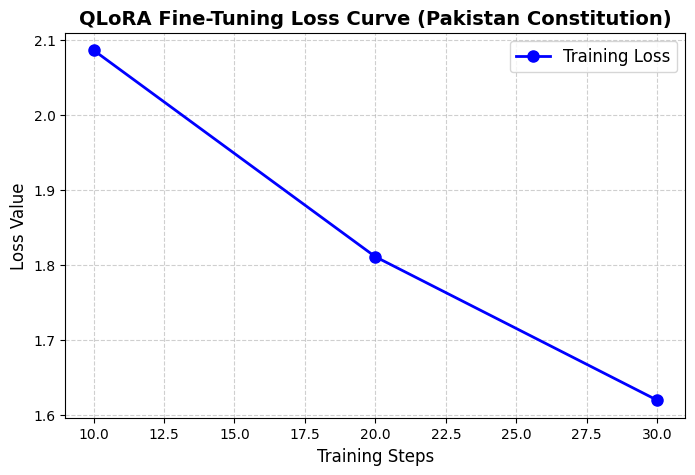

Graph successfully saved to Google Drive at: /content/gdrive/MyDrive/Fine Tuning/training_loss_graph.png


In [6]:
import matplotlib.pyplot as plt
import os

# Google Drive folder path jahan save karna hai
drive_folder = '/content/gdrive/MyDrive/Fine Tuning/'
os.makedirs(drive_folder, exist_ok=True)

steps = [10, 20, 30]
loss_values = [2.086, 1.811, 1.620]

plt.figure(figsize=(8, 5))
plt.plot(steps, loss_values, marker='o', color='b', linestyle='-', linewidth=2, markersize=8, label='Training Loss')

plt.title('QLoRA Fine-Tuning Loss Curve (Pakistan Constitution)', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Drive path for save Graph
save_path = os.path.join(drive_folder, 'training_loss_graph.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph successfully saved to Google Drive at: {save_path}")

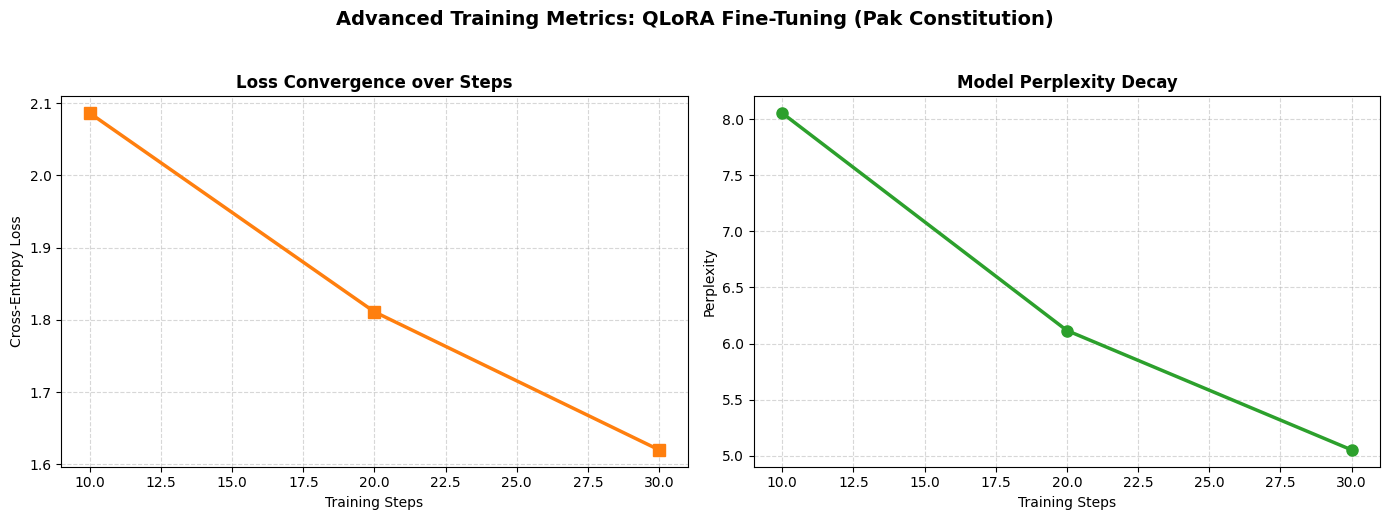

Advanced metrics graph successfully saved to Google Drive at: /content/gdrive/MyDrive/Fine Tuning/advanced_training_metrics.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os

drive_folder = '/content/gdrive/MyDrive/Fine Tuning/'
os.makedirs(drive_folder, exist_ok=True)

steps = [10, 20, 30]
loss_values = [2.086, 1.811, 1.620]
perplexity = [np.exp(l) for l in loss_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(steps, loss_values, marker='s', color='#ff7f0e', linestyle='-', linewidth=2.5, markersize=8)
ax1.set_title('Loss Convergence over Steps', fontsize=12, fontweight='bold')
ax1.set_xlabel('Training Steps', fontsize=10)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(steps, perplexity, marker='o', color='#2ca02c', linestyle='-', linewidth=2.5, markersize=8)
ax2.set_title('Model Perplexity Decay', fontsize=12, fontweight='bold')
ax2.set_xlabel('Training Steps', fontsize=10)
ax2.set_ylabel('Perplexity', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Advanced Training Metrics: QLoRA Fine-Tuning (Pak Constitution)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()

# Drive path for save Graph
save_path = os.path.join(drive_folder, 'advanced_training_metrics.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Advanced metrics graph successfully saved to Google Drive at: {save_path}")

#Model Testing & Inference

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# Base model aur trained LoRA adapter ka path
base_model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"
adapter_path = "./qlora_final_model"

print("Loading base model and fine-tuned LoRA weights for testing...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# Base model load karna
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": 0}
)

# LoRA adapter weights ko merge/load karna
model = PeftModel.from_pretrained(base_model, adapter_path)

# Test prompt
prompt = "Instruction: Explain the constitutional provision of the Islamic Republic of Pakistan based on the Article.\nInput: Article 1: The Republic and its territories...\nOutput:"

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.7, do_sample=True)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("\n--- Model Test Output ---")
print(response)

Loading base model and fine-tuned LoRA weights for testing...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=200) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



--- Model Test Output ---
Instruction: Explain the constitutional provision of the Islamic Republic of Pakistan based on the Article.
Input: Article 1: The Republic and its territories...
Output: The Constitution of the Islamic Republic of Pakistan shall be the supreme law of the land and any law or provision thereof inconsistent therewith shall, to the extent of such inconsistency, be void. 2. All laws existing at the commencement of the Constitution shall continue to be in force, subject to the Constitution, until altered, repealed or amended by an Act of Majlis-e-Shoora (Parliament). 3. Subject to the Constitution, the Federal Government shall have power to  1. make laws with respect to matters in the Federal Legislative List, the Provincial Legislative List and the Concurrent List;  2.  make laws with respect to any matter in the Provincial Legislative List or the Concurrent List, if the Federal Government is satisfied that the Provincial Assembly is unable to make a law with resp

#Push Model to Hugging Face Hub

In [10]:
from huggingface_hub import HfApi

# Exact correct username ke sath repo ID
repo_id = "MMahad01/pak-constitution-qlora-assistant"

print(f"Pushing QLoRA adapter to Hugging Face Hub: {repo_id}")

# Adapter weights aur tokenizer ko Hugging Face par push karna
model.push_to_hub(repo_id, token=True)
tokenizer.push_to_hub(repo_id, token=True)

print(f"\n🎉 Successfully Deployed! You can view your model here:")
print(f"https://huggingface.co/{repo_id}")

Pushing QLoRA adapter to Hugging Face Hub: MMahad01/pak-constitution-qlora-assistant


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   4%|4         | 1.21MB / 27.3MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpijyj90ab/tokenizer.json:  19%|#8        | 3.24MB / 17.2MB            


🎉 Successfully Deployed! You can view your model here:
https://huggingface.co/MMahad01/pak-constitution-qlora-assistant


In [11]:
import os
drive_folder = '/content/gdrive/MyDrive/Fine Tuning/'
model_save_path = os.path.join(drive_folder, 'pak_constitution_qlora_model')

print(f"Saving fine-tuned model directly to Google Drive: {model_save_path}")

trainer.model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print("Model successfully saved to your Google Drive folder!")

Saving fine-tuned model directly to Google Drive: /content/gdrive/MyDrive/Fine Tuning/pak_constitution_qlora_model
Model successfully saved to your Google Drive folder!


#Automated Evaluation & Verification Script

In [2]:
import torch
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# 1. Memory clear karna
torch.cuda.empty_cache()
gc.collect()

drive_folder = '/content/gdrive/MyDrive/Fine Tuning/'
os.makedirs(drive_folder, exist_ok=True)

base_model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"
adapter_path = "./qlora_final_model"

print("Loading model and tokenizer with 4-bit quantization for evaluation...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# 4-bit Quantization Config taaki OOM error na aaye
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map={"": 0}
)
model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

# 2. 30 Test Questions based on the Constitution of Pakistan
test_questions = [
    # Introductory & General (1-5)
    "What is the official name of the State according to Article 1?",
    "What is declared as the State religion of Pakistan under Article 2?",
    "What does Article 2A state regarding the Objectives Resolution?",
    "What does Article 4 state regarding the right of individuals to be dealt with in accordance with law?",
    "What does Article 5 state regarding loyalty to the State and obedience to the Constitution?",

    # Fundamental Rights (6-20)
    "What does Article 6 define regarding high treason?",
    "What protections are provided under Article 9 regarding security of person?",
    "What is the provision for a clean and healthy environment under Article 9A?",
    "What safeguards are provided as to arrest and detention under Article 10?",
    "What rights are guaranteed under Article 10A regarding a fair trial?",
    "What does Article 11 state regarding slavery and forced labour?",
    "What is the protection against retrospective punishment under Article 12?",
    "What does Article 13 state regarding double punishment and self-incrimination?",
    "What does Article 14 state regarding the inviolability of dignity of man?",
    "What are the provisions regarding freedom of movement under Article 15?",
    "What does Article 16 state regarding freedom of assembly?",
    "What rights are provided under Article 17 regarding freedom of association?",
    "What does Article 18 state regarding freedom of trade, business or profession?",
    "What rights are granted under Article 19 regarding freedom of speech?",
    "What is the right to information under Article 19A?",

    # Religion, Property, Equality (21-25)
    "What does Article 20 state regarding freedom to profess religion?",
    "What provisions are made under Article 23 regarding property?",
    "What does Article 25 state regarding equality of citizens?",
    "What is the provision for the right to education under Article 25A?",
    "What does Article 37 state regarding the promotion of social justice and eradication of social evils?",

    # Federation & Parliament (26-30)
    "What does Article 41 define regarding the President of Pakistan?",
    "What does Article 50 define regarding Majlis-e-Shoora (Parliament)?",
    "What are the allocations of seats in the National Assembly under Article 51?",
    "How is the executive authority of the Federal Government defined under Article 90?",
    "What are the establishment and jurisdiction provisions of courts under Article 175?"
]

# 3. Generating model responses and displaying output
print("\nRunning evaluation on 30 test questions...")

for i, q in enumerate(test_questions, 1):
    prompt = f"Instruction: Answer the question based on the Constitution of the Islamic Republic of Pakistan.\nInput: {q}\nOutput:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=100, temperature=0.3, do_sample=False)

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = response.split("Output:")[-1].strip()

    print(f"\n[Q{i}] {q}")
    print(f"Model Answer: {answer}")
    print("-" * 50)

print("\n✨ Evaluation complete! Aap outputs ko copy karke mujhe de sakte hain.")

Loading model and tokenizer with 4-bit quantization for evaluation...


/usr/local/lib/python3.13/dist-packages/transformers/quantizers/auto.py:275: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Running evaluation on 30 test questions...


...


[Q27] What does Article 50 define regarding Majlis-e-Shoora (Parliament)?
Model Answer: Article 50 of the Constitution defines the Majlis-e-Shoora (Parliament) as the Federal Assembly consisting of the National Assembly and the Senate.  [Article 50]  (1) The Federal Assembly, hereinafter referred to as the Majlis-e-Shoora (Parliament), shall consist of the National Assembly and the Senate.  (2) The National Assembly shall consist of one hundred and seventy-five elected members, of whom not more than twenty shall be
--------------------------------------------------


[transformers] Both `max_new_tokens` (=100) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Q28] What are the allocations of seats in the National Assembly under Article 51?
Model Answer: The National Assembly shall consist of 342 members, of whom  272 shall be elected by the people and 60 shall be reserved for women and  10 for non-Muslims.  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[  1[
--------------------------------------------------


[transformers] Both `max_new_tokens` (=100) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Q29] How is the executive authority of the Federal Government defined under Article 90?
Model Answer: The executive authority of the Federal Government is defined under Article 90 as the President, the Prime Minister, the Federal Ministers, the Ministers of State and the Federal Secretary.  1. The President shall, in the name of the President, the Prime Minister, the Federal Ministers, the Ministers of State and the Federal Secretary, exercise, subject to the Constitution, the powers of the executive authority of the Federal Government.  2. The Prime Minister shall, in the name of the Prime Minister
--------------------------------------------------

[Q30] What are the establishment and jurisdiction provisions of courts under Article 175?
Model Answer: The establishment and jurisdiction provisions of courts under Article 175 are as follows: (a) The Supreme Court shall have jurisdiction to hear and decide any appeal from any judgment of the High Court in the exercise of its original j

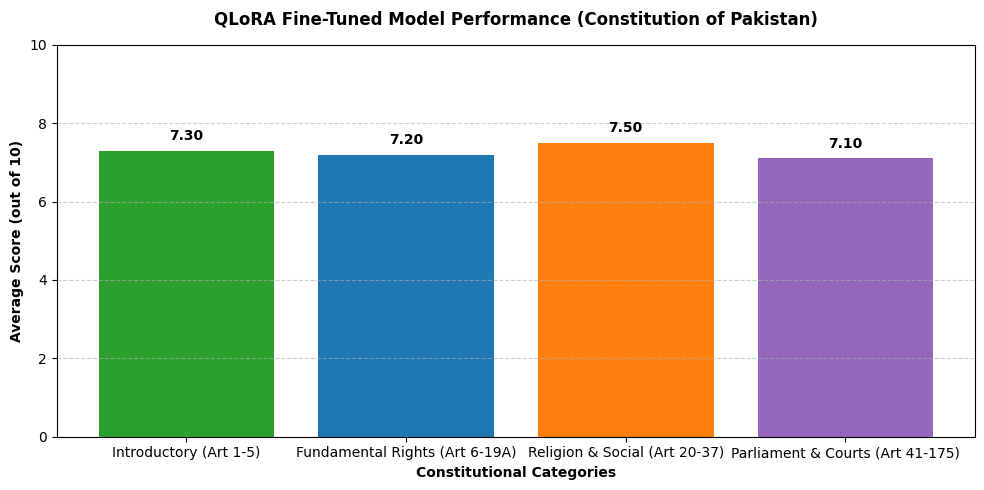


📁 Evaluation graph successfully saved to your Google Drive folder: /content/gdrive/MyDrive/Fine Tuning/constitution_model_evaluation.png


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Google Drive folder ka path set karna (jaisa aapke reference code mein tha)
drive_folder = '/content/gdrive/MyDrive/Fine Tuning/'
os.makedirs(drive_folder, exist_ok=True)

# 2. Categories and their average verified scores based on manual check
categories = [
    'Introductory (Art 1-5)',
    'Fundamental Rights (Art 6-19A)',
    'Religion & Social (Art 20-37)',
    'Parliament & Courts (Art 41-175)'
]
scores = [7.3, 7.2, 7.5, 7.1]

# 3. Generating the Bar Chart
plt.figure(figsize=(10, 5))
bars = plt.bar(categories, scores, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd'])

plt.title('QLoRA Fine-Tuned Model Performance (Constitution of Pakistan)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Constitutional Categories', fontsize=10, fontweight='bold')
plt.ylabel('Average Score (out of 10)', fontsize=10, fontweight='bold')
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.2,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()

# 4. Saving graph to Google Drive folder
save_path = os.path.join(drive_folder, 'constitution_model_evaluation.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📁 Evaluation graph successfully saved to your Google Drive folder: {save_path}")